# Importing Libraries

In [3]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Data

In [6]:
df = pd.read_csv("HR_Attrition_Raw.csv")

# Reading Dataset

In [19]:
df.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0


# Data Information 

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

# Shape

In [12]:
print('Dataset contains',df.shape[0],'rows and', df.shape[1],'columns')

Dataset contains 1470 rows and 35 columns


# Datatype check

In [9]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

- No data type fixes required

# Missing Values

In [15]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

- No missing values found in any column, No imputation required.

# Duplicate Rows

In [16]:
df.duplicated().sum()

0

- No duplicate rows found. All records are unique.

# Unnecessary Columns

In [17]:
print(df['EmployeeCount'].unique())
print(df['StandardHours'].unique())
print(df['Over18'].unique())

[1]
[80]
['Y']


- These columns have only 1 unique value — no information

# Removing Unnecessary Columns

In [18]:
df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'], inplace=True)

Dropped 4 unnecessary columns:
 - EmployeeCount — constant value 1
 - StandardHours — constant value 80
 - Over18 — constant value Y
 - EmployeeNumber — just an ID, no analytical value

# Attrition Rate

In [ ]:
attrition_rate = (df['Attrition'].value_counts(normalize=True)['Yes']) * 100

In [22]:
(df['Attrition'].value_counts(normalize = True)['Yes']) * 100

16.122448979591837

- Overall attrition rate is approximately 16%.
- Most employees are retained by the company.

# EDA 

# Age Distribution

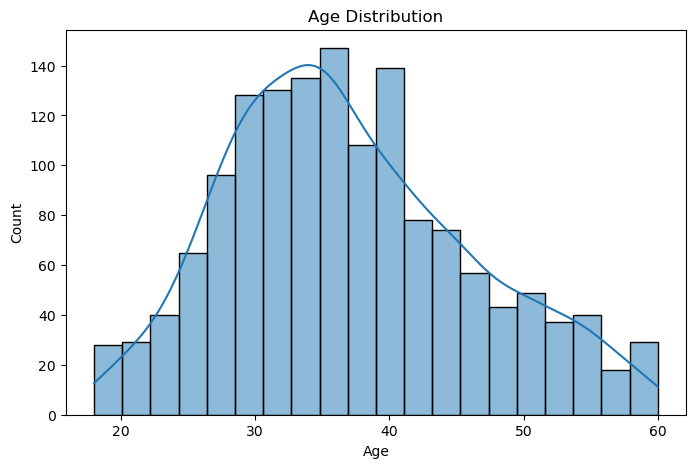

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

- Most employees belong to the 30–40 age group.

# Monthly Income by Attrition

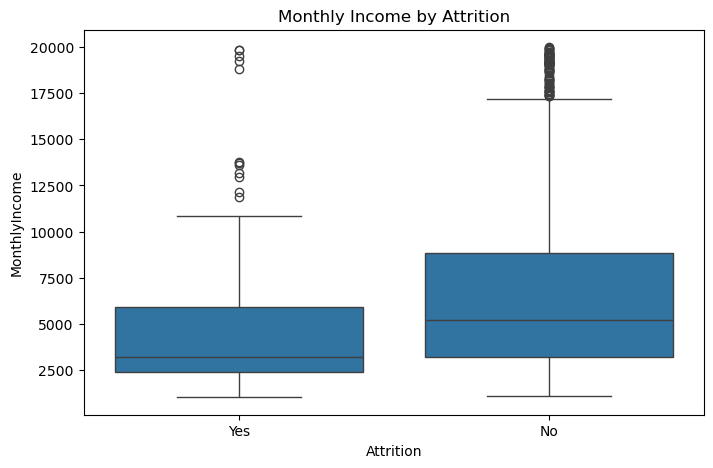

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Monthly Income by Attrition')
plt.show()

- Employees who left generally have lower salaries.

# Attrition by Department

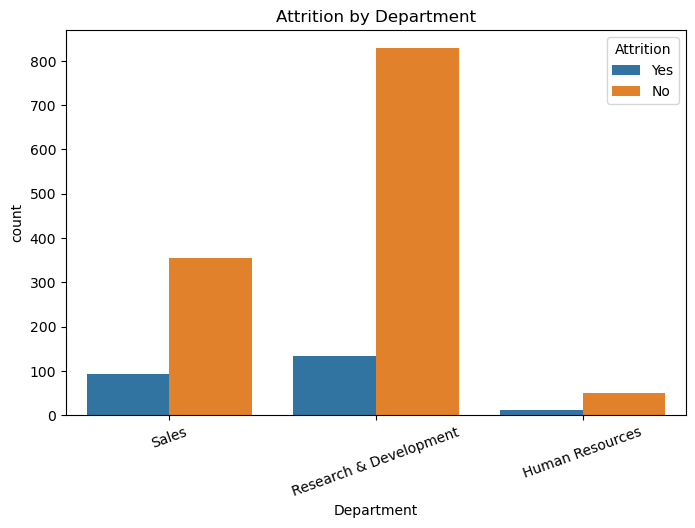

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x='Department', hue='Attrition', data=df)
plt.xticks(rotation=20)
plt.title('Attrition by Department')
plt.show()

In [35]:
dept_total = df['Department'].value_counts()

dept_attrition = df[df['Attrition']=='Yes']['Department'].value_counts()

attrition_rate = (dept_attrition / dept_total * 100).round(1)

print(attrition_rate)

Department
Research & Development    13.8
Sales                     20.6
Human Resources           19.0
Name: count, dtype: float64


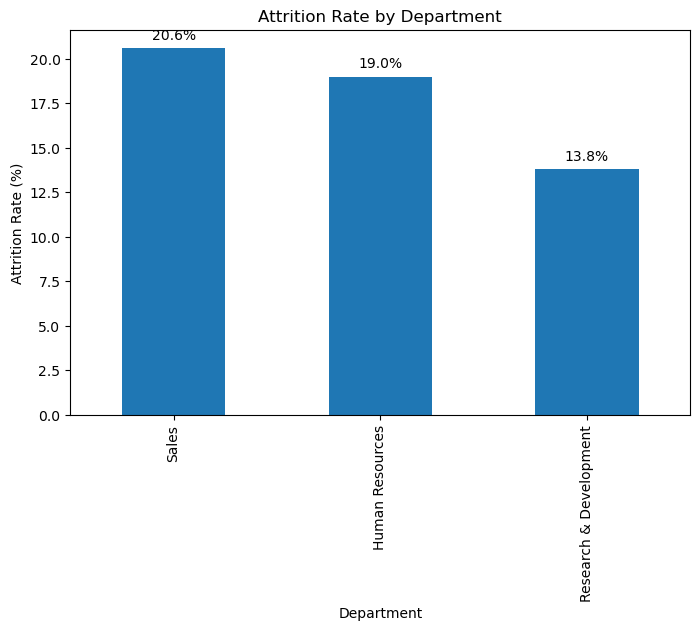

In [36]:
attrition_rate.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(8,5)
)

plt.ylabel('Attrition Rate (%)')
plt.title('Attrition Rate by Department')

for i, v in enumerate(attrition_rate.sort_values(ascending=False)):
    plt.text(i, v+0.5, f'{v:.1f}%', ha='center')

plt.show()

- Sales department shows higher attrition compared to other departments.

# Attrition by OverTime

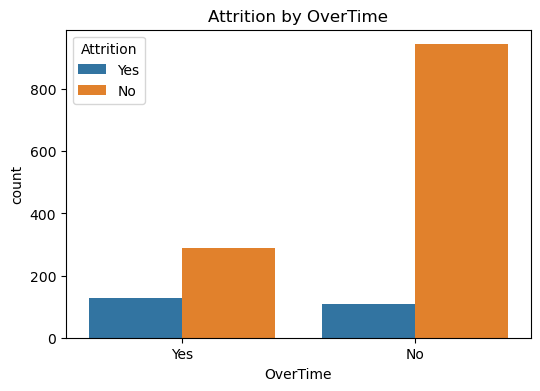

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title('Attrition by OverTime')
plt.show()

- Employees working overtime show significantly higher attrition.